## LAB 1: Introduction to Python and Libraries for Machine Learning, Environmental Setup

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')


## LAB 2: Handling missing values, data normalization, standardization, Data visualization using Matplotlib and Seaborn

Fever                      0
Tiredness                  0
Dry-Cough                  0
Difficulty-in-Breathing    0
Sore-Throat                0
None_Sympton               0
Pains                      0
Nasal-Congestion           0
Runny-Nose                 0
Diarrhea                   0
None_Experiencing          0
Age_0-9                    0
Age_10-19                  0
Age_20-24                  0
Age_25-59                  0
Age_60+                    0
Gender_Female              0
Gender_Male                0
Gender_Transgender         0
Severity_Mild              0
Severity_Moderate          0
Severity_None              0
Severity_Severe            0
Contact_Dont-Know          0
Contact_No                 0
Contact_Yes                0
dtype: int64


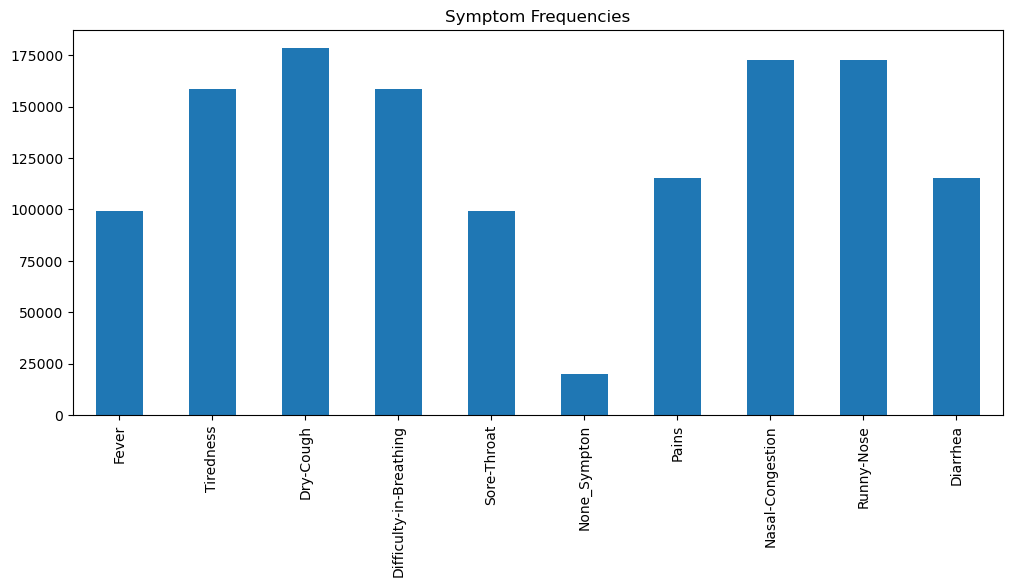

In [5]:

df = pd.read_csv('Cleaned-Data.csv')
df.head()

# Check for missing values
print(df.isnull().sum())

# Plotting distribution of some features
df.iloc[:, :10].sum().plot(kind='bar', figsize=(12,5), title='Symptom Frequencies')
plt.show()


## LAB 3: Data preprocessing (Correlation, Outlier detection, feature engineering, Data Splitting)

Outliers per feature: Fever                          0
Tiredness                      0
Dry-Cough                      0
Difficulty-in-Breathing        0
Sore-Throat                    0
None_Sympton               19800
Pains                          0
Nasal-Congestion               0
Runny-Nose                     0
Diarrhea                       0
None_Experiencing          28800
Age_0-9                    63360
Age_10-19                  63360
Age_20-24                  63360
Age_25-59                  63360
Age_60+                    63360
Gender_Female                  0
Gender_Male                    0
Gender_Transgender             0
Contact_Dont-Know              0
Contact_No                     0
Contact_Yes                    0
dtype: int64


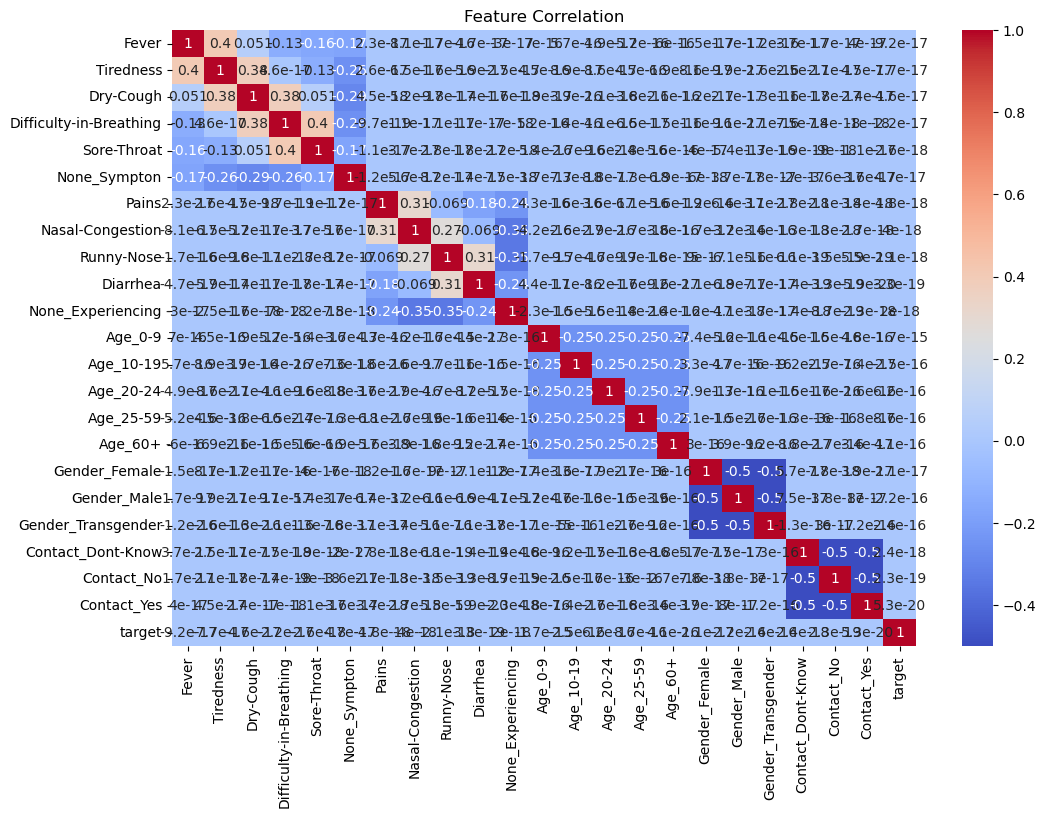

In [10]:

df['target'] = df['Severity_Mild'] + df['Severity_Moderate'] + df['Severity_Severe']
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe', ])

X = df.drop(columns=['target'])
y = df['target']

# Outlier detection using IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).sum()
print("Outliers per feature:", outliers)

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## LAB 5: Logistic Regression for binary classification, Model evaluation using metrics (R², MAE, MSE)

In [13]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7513099747474747
R²: -0.33100854988131
MAE: 0.24869002525252526
MSE: 0.24869002525252526


## LAB 6: Implementing Decision Tree

In [16]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7513099747474747
Confusion Matrix:
 [[    0 15757]
 [    0 47603]]
Precision: 0.7513099747474747
Recall: 1.0
F1 Score: 0.8579977109486946


## LAB 7: Implementing Support Vector Machine

## LAB 8: Evaluation Matrices for classification (accuracy, confusion matrix, AUC / ROC curve, precision, recall and F1-score)

## User Input Prediction Example

In [ ]:

def user_input():
    print("Enter symptoms (yes/no):")
    features = {}
    for feature in X.columns:
        val = input(f"{feature}: ").lower()
        features[feature] = 1 if val == 'yes' else 0
    return pd.DataFrame([features])

# Uncomment below lines to enable user input in console
# user_df = user_input()
# prediction = lr.predict(user_df)[0]
# print("Prediction: COVID Positive" if prediction == 1 else "Prediction: COVID Negative")
